# MC62 — Validation: Our Analyzer vs FFMM (C++ Pipeline)

**Magnet**: MC62 (red bulk C-shaped dipole)
**Test**: `02_staircase_without_shims` (2026-02-12)
**Purpose**: Compare harmonic results from our Python rotating-coil analyzer
against the reference FFMM C++ pipeline output.

---

## Strategy

The FFMM software produces `MC62_*_Average_results.txt` files containing
per-plateau averaged harmonics. We run our Kn pipeline on the same raw data
and compare:

1. **B_main** (main field in Tesla)
2. **b2–b15, a2–a15** (harmonics in units, i.e. 10⁻⁴ relative to main)
3. **Transfer function** (B1/I)

Because the FFMM may average over a different number of turns than our
default `N_LAST_TURNS = 170`, we sweep the averaging window to find
the best match and quantify residual differences.

## 1. Configuration

In [1]:
from pathlib import Path
import numpy as np

# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\MC62\2026-02-11")
TEST_DIR    = BASE_DIR / "02_staircase_without_shims" / "20260212_075344_staircase_without_shims_MC62"
RUN_DIR     = TEST_DIR / "20260212_100000_MC62"
KN_DIR      = BASE_DIR / "Kn values"

KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # integral (long) PCB
KN_CENTRAL  = KN_DIR / "Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"  # central (small) PCB

# FFMM average results (C++ pipeline output)
FFMM_INTEGRAL = TEST_DIR / "MC62_Integral_Average_results.txt"
FFMM_CENTRAL  = TEST_DIR / "MC62_Central_Average_results.txt"

# ── Magnet & coil parameters ──────────────────────────────────────────
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]
SAMPLES_PER_TURN = 1024     # encoder resolution

# ── Sign convention ───────────────────────────────────────────────────
FLIP_SIGNAL_POLARITY = False    # True = negate all harmonics (inverted coil/cable polarity)
ENCODER_OFFSET_RAD = np.pi    # 180-deg encoder offset (MC62 2024 vs 2022 convention)

# ── Pipeline options ──────────────────────────────────────────────────
# FFMM reference used: dri rot nor cel fed dit.
# dit is N/A here: comparison is on plateau-averaged values (dI/dt ~ 0).
# For per-turn parity with dit, see the MC62 03 analysis notebook.
OPTIONS    = ("dri", "rot", "cel", "fed")
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    discover_runs,
    plateau_summary,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

## 3. Load FFMM Reference Results

Parse the tab-separated FFMM average-results files.
Key columns:
- `B_main(T)` — actual main field in Tesla (our `B1_T`)
- `b2(Units)` … `b15(Units)` — harmonics in units (our `b2_units` … `b15_units`)
- `a2(Units)` … `a15(Units)` — skew harmonics
- `I(A)` — nominal current

In [3]:
def load_ffmm_results(path):
    """Load FFMM average results into a tidy DataFrame."""
    df = pd.read_csv(path, sep="\t", skipinitialspace=True)
    # Clean column names (remove trailing spaces)
    df.columns = [c.strip() for c in df.columns]
    return df

ffmm_int = load_ffmm_results(FFMM_INTEGRAL)
ffmm_cen = load_ffmm_results(FFMM_CENTRAL)

print(f"FFMM Integral: {len(ffmm_int)} rows, columns: {list(ffmm_int.columns[:10])} ...")
print(f"FFMM Central:  {len(ffmm_cen)} rows")
print(f"\nCurrent levels: {ffmm_int['I(A)'].round(0).astype(int).tolist()}")
print(f"\nFFMM Integral sample (40 A):")
row40 = ffmm_int[ffmm_int['I(A)'].round(0) == 40].iloc[0]
print(f"  B_main = {row40['B_main(T)']:.6f} T")
print(f"  b2     = {row40['b2(Units)']:.2f} units")
print(f"  b3     = {row40['b3(Units)']:.2f} units")

# Flag corrupt Central rows (FFMM bug: some B_main values are nonsensical)
corrupt_mask = ffmm_cen["B_main(T)"].abs() > 1.0
n_corrupt = corrupt_mask.sum()
if n_corrupt > 0:
    msg = f"\nWARNING: {n_corrupt} Central FFMM rows have corrupt B_main (|B_main| > 1 T):"
    print(msg)
    for _, row in ffmm_cen[corrupt_mask].iterrows():
        print(f"  I={row['I(A)']:+8.1f} A: B_main = {row['B_main(T)']:+.3e} T")
    print("These rows will be excluded from Central comparisons.")

FFMM Integral: 41 rows, columns: ['Time(s)', 'Duration(s)', 'Options', 'Rref(m)', 'Lcoil(m)', 'I(A)', 'Ramprate(A/s)', 'dx(mm)', 'dy(mm)', 'phi(rad)'] ...
FFMM Central:  41 rows

Current levels: [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 180, 160, 140, 120, 100, 80, 60, 40, 20, 0, -20, -40, -60, -80, -100, -120, -140, -160, -180, -200, -180, -160, -140, -120, -100, -80, -60, -40, -20, 0]

FFMM Integral sample (40 A):
  B_main = -0.051201 T
  b2     = -16.69 units
  b3     = -17.72 units

  I=   +20.0 A: B_main = +8.251e+03 T
  I=  +180.0 A: B_main = -1.078e+03 T
  I=  +120.0 A: B_main = -3.124e+05 T
  I=  -120.0 A: B_main = -4.289e+00 T
  I=   -60.0 A: B_main = -1.395e+03 T
These rows will be excluded from Central comparisons.


## 4. Run Our Pipeline on Raw Data

Process all 41 runs through the Kn pipeline, keeping **all** 350 turns per run
(no truncation). We will compute averages over different `N_LAST` windows later.

In [4]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
kn_central  = load_segment_kn_txt(str(KN_CENTRAL))

Ns = SAMPLES_PER_TURN
runs_integral = discover_runs(RUN_DIR, "Integral")
runs_central  = discover_runs(RUN_DIR, "Central")
print(f"Found {len(runs_integral)} integral runs, {len(runs_central)} central runs")

def process_all_turns(runs, kn, label, merge_mode="abs_upto_m_cmp_above"):
    """Run full pipeline on all turns of every run, return turn-level DataFrame."""
    all_rows = []
    peak_run = max(runs, key=lambda r: abs(r["I_nom"]))
    raw_peak = np.loadtxt(peak_run["file"])
    rr1 = robust_range(raw_peak[:, 1])
    rr2 = robust_range(raw_peak[:, 2])
    swap = rr2 > rr1
    print(f"[{label}] swap={swap} | merge: {merge_mode}")

    # Hysteresis branches
    I_noms = [r["I_nom"] for r in runs]
    branches = ["ascending"]
    for i in range(1, len(I_noms)):
        if I_noms[i] > I_noms[i - 1]:
            branches.append("ascending")
        elif I_noms[i] < I_noms[i - 1]:
            branches.append("descending")
        else:
            branches.append(branches[-1])

    for ri, run_info in enumerate(runs):
        raw = np.loadtxt(run_info["file"])
        n_turns = raw.shape[0] // Ns
        raw = raw[:n_turns * Ns]
        t_turns  = raw[:, 0].reshape(n_turns, Ns)
        ch1      = raw[:, 1].reshape(n_turns, Ns)
        ch2      = raw[:, 2].reshape(n_turns, Ns)
        flux_abs = ch2 if swap else ch1
        flux_cmp = ch1 if swap else ch2
        I_turns  = raw[:, 3].reshape(n_turns, Ns)
        try:
            result, C_merged, C_units, ok_main = process_kn_pipeline(
                flux_abs, flux_cmp, t_turns, I_turns, kn, R_REF,
                MAGNET_ORDER, options=OPTIONS, drift_mode=DRIFT_MODE,
                min_b1_T=MIN_B1_T, merge_mode=merge_mode,
                flip_signal_polarity=FLIP_SIGNAL_POLARITY,
                encoder_offset_rad=ENCODER_OFFSET_RAD,
            )
            extra = [{"run_id": run_info["run_id"],
                       "I_nom": run_info["I_nom"],
                       "branch": branches[ri],
                       "turn_in_run": t,
                       "pcb": label}
                      for t in range(n_turns)]
            rows = build_harmonic_rows(
                result, C_merged, C_units, ok_main,
                MAGNET_ORDER, extra)
            all_rows.extend(rows)
        except Exception as e:
            print(f"  Run {run_info['run_id']:02d} ({run_info['I_nom']:+7.1f} A): FAILED - {e}")

    df = pd.DataFrame(all_rows)
    return df

print("Processing Integral PCB (R45)...")
df_int = process_all_turns(runs_integral, kn_integral, "Integral")
print(f"Processing Central PCB (DQ)...")
df_cen = process_all_turns(runs_central, kn_central, "Central", merge_mode="abs_all")

print(f"\nIntegral: {len(df_int)} rows  |  Central: {len(df_cen)} rows")

Found 41 integral runs, 41 central runs
Processing Integral PCB (R45)...


[Integral] swap=False | merge: abs_upto_m_cmp_above


Processing Central PCB (DQ)...


[Central] swap=False | merge: abs_all



Integral: 14351 rows  |  Central: 14351 rows


## 4b. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on the highest-|I| run for each PCB to check
whether the centre-location + feeddown correction is safe for this data.
For dipoles, cel uses compensated harmonics n=10,11 which can be pure
noise at low SNR. See `correction_options_reference.md` for background.

In [5]:
def _cel_fed_check(runs, kn, label):
    """Run cel/fed diagnostic on the highest-|I| run."""
    peak = max(runs, key=lambda r: abs(r["I_nom"]))
    raw = np.loadtxt(peak["file"])
    nt = raw.shape[0] // Ns
    raw = raw[:nt * Ns]
    rr1, rr2 = robust_range(raw[:, 1]), robust_range(raw[:, 2])
    sw = rr2 > rr1
    shape = (nt, Ns)
    t = raw[:, 0].reshape(shape)
    fa = raw[:, 2 if sw else 1].reshape(shape)
    fc = raw[:, 1 if sw else 2].reshape(shape)
    Ia = raw[:, 3].reshape(shape)
    d = diagnose_cel_fed(fa, fc, t, Ia, kn=kn, r_ref=R_REF,
                         magnet_order=MAGNET_ORDER)
    print(f"[{label}] Run {peak['run_id']} (I={peak['I_nom']:+.0f} A): "
          f"{d.recommendation}")
    print(f"  {d.reason}")
    Bd = np.max(np.abs(d.B_main_with_fed - d.B_main_without_fed))
    print(f"  B_main max |diff|: {Bd:.4e} T\n")
    return d

diag_int = _cel_fed_check(runs_integral, kn_integral, "Integral")
diag_cen = _cel_fed_check(runs_central, kn_central, "Central")

# Act on diagnostic: disable cel/fed if either segment is unsafe
if diag_int.recommendation == "UNSAFE" or diag_cen.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"\ncel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"\ncel/fed safe, keeping OPTIONS = {OPTIONS}")


[Integral] Run 10 (I=+200 A): UNSAFE
  350/350 turns (100%) have |zR| > 0.0100 (median 0.1206, max 0.2080). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 2.8467e-05 T



[Central] Run 10 (I=+200 A): UNSAFE
  342/350 turns (98%) have |zR| > 0.0100 (median 0.0584, max 0.5667). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 5.7793e-05 T


cel/fed disabled, OPTIONS = ('dri', 'rot')


## 5. Find Best Averaging Window

The FFMM averages over some number of turns per plateau. We sweep
`N_LAST` from 50 to 350 and find the window that minimises the RMS
difference in B_main across all 41 plateaus.

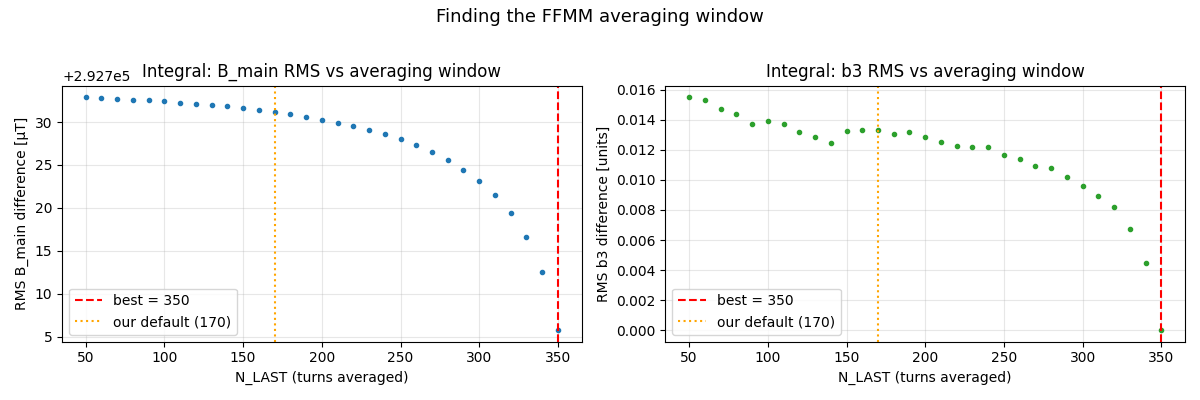


Best N_LAST for Integral B_main match: 350 turns
  RMS B_main = 292705.77 µT
  RMS b3     = 0.000 units


In [6]:
def compute_our_averages(df, n_last):
    """Compute per-run averages over the last n_last turns."""
    records = []
    for run_id in sorted(df["run_id"].unique()):
        rdf = df[df["run_id"] == run_id].sort_values("turn_in_run")
        if len(rdf) < n_last:
            tail = rdf
        else:
            tail = rdf.iloc[-n_last:]
        rec = {"run_id": run_id, "I_nom": rdf["I_nom"].iloc[0]}
        rec["B1_mean"] = tail["B1_T"].mean()
        for n in range(2, 16):
            bc = f"b{n}_units"
            ac = f"a{n}_units"
            if bc in tail.columns:
                rec[f"b{n}_mean"] = tail[bc].mean()
            if ac in tail.columns:
                rec[f"a{n}_mean"] = tail[ac].mean()
        records.append(rec)
    return pd.DataFrame(records)

# Sweep N_LAST for Integral
n_last_values = list(range(50, 351, 10))
rms_B1_vs_nlast = []
rms_b3_vs_nlast = []

ffmm_B1_int = ffmm_int["B_main(T)"].values
ffmm_b3_int = ffmm_int["b3(Units)"].values

for n_last in n_last_values:
    our = compute_our_averages(df_int, n_last)
    # RMS of B_main difference (exclude near-zero where relative error is meaningless)
    mask = our["I_nom"].abs() >= 10
    diff_B1 = our.loc[mask, "B1_mean"].values - ffmm_B1_int[mask.values]
    rms_B1_vs_nlast.append(np.sqrt(np.mean(diff_B1**2)))
    # b3
    if "b3_mean" in our.columns:
        diff_b3 = our.loc[mask, "b3_mean"].values - ffmm_b3_int[mask.values]
        rms_b3_vs_nlast.append(np.sqrt(np.mean(diff_b3**2)))
    else:
        rms_b3_vs_nlast.append(np.nan)

best_idx = np.argmin(rms_B1_vs_nlast)
best_n_last = n_last_values[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(n_last_values, np.array(rms_B1_vs_nlast) * 1e6, "o", ms=3)
ax.axvline(best_n_last, color="red", ls="--", label=f"best = {best_n_last}")
ax.axvline(170, color="orange", ls=":", label="our default (170)")
ax.set_xlabel("N_LAST (turns averaged)")
ax.set_ylabel("RMS B_main difference [µT]")
ax.set_title("Integral: B_main RMS vs averaging window")
ax.legend()

ax = axes[1]
ax.plot(n_last_values, rms_b3_vs_nlast, "o", ms=3, color="tab:green")
ax.axvline(best_n_last, color="red", ls="--", label=f"best = {best_n_last}")
ax.axvline(170, color="orange", ls=":", label="our default (170)")
ax.set_xlabel("N_LAST (turns averaged)")
ax.set_ylabel("RMS b3 difference [units]")
ax.set_title("Integral: b3 RMS vs averaging window")
ax.legend()

fig.suptitle("Finding the FFMM averaging window", fontsize=13)
fig.tight_layout()
plt.show()

print(f"\nBest N_LAST for Integral B_main match: {best_n_last} turns")
print(f"  RMS B_main = {rms_B1_vs_nlast[best_idx]*1e6:.2f} µT")
print(f"  RMS b3     = {rms_b3_vs_nlast[best_idx]:.3f} units")

## 6. Detailed Comparison at Best N_LAST

Compare our pipeline output against FFMM at the best-matching averaging window.
Show B_main, b2, b3 comparisons for both Integral and Central PCBs.

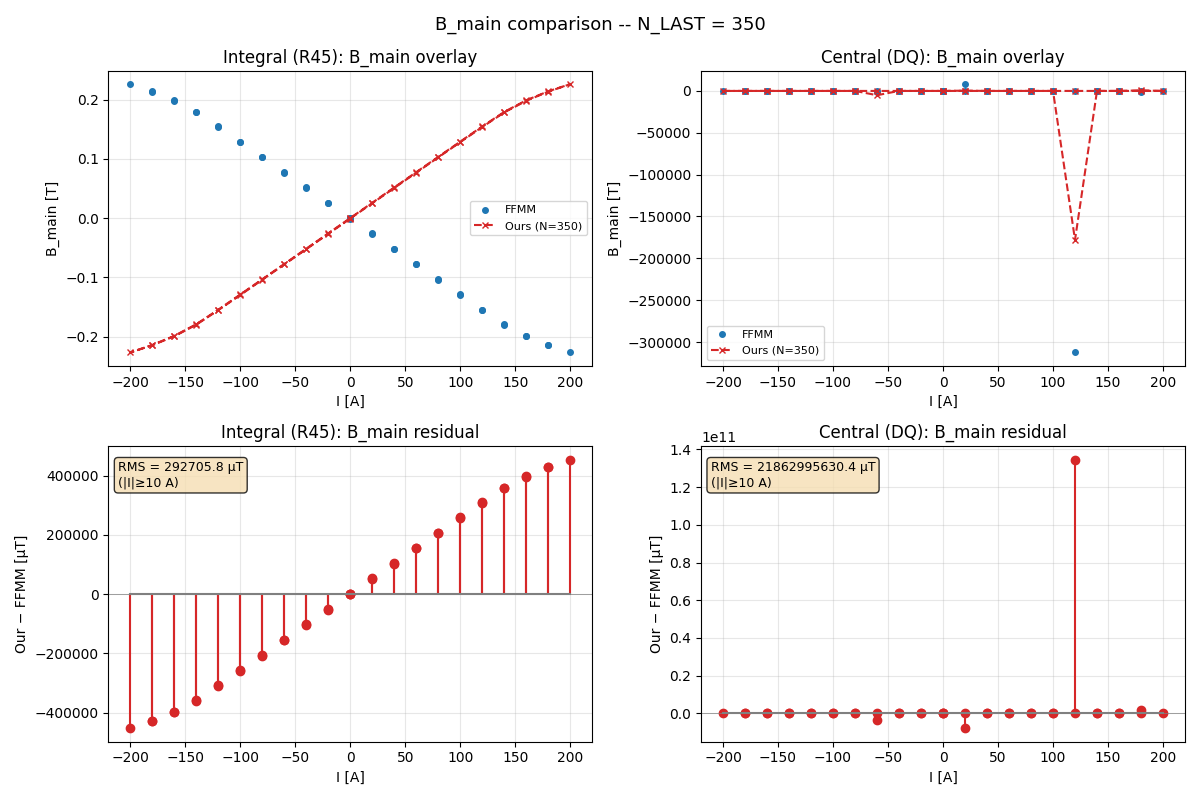

In [7]:
N_COMPARE = best_n_last

our_int = compute_our_averages(df_int, N_COMPARE)
our_cen = compute_our_averages(df_cen, N_COMPARE)

# For Central, mask out corrupt FFMM rows
cen_ok_mask = ffmm_cen["B_main(T)"].abs() <= 1.0

# ── B_main comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col_idx, (our, ffmm, label) in enumerate([
    (our_int, ffmm_int, "Integral (R45)"),
    (our_cen, ffmm_cen, "Central (DQ)"),
]):
    ffmm_B1 = ffmm["B_main(T)"].values
    our_B1  = our["B1_mean"].values
    I_vals  = our["I_nom"].values

    # Top: overlay
    ax = axes[0, col_idx]
    ax.plot(I_vals, ffmm_B1, "o", ms=4, label="FFMM", color="tab:blue")
    ax.plot(I_vals, our_B1, "x--", ms=4, label=f"Ours (N={N_COMPARE})", color="tab:red")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("B_main [T]")
    ax.set_title(f"{label}: B_main overlay")
    ax.legend(fontsize=8)

    # Bottom: residual
    ax = axes[1, col_idx]
    diff = (our_B1 - ffmm_B1) * 1e6  # µT
    ax.stem(I_vals, diff, linefmt="tab:red", markerfmt="o", basefmt="gray")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("Our − FFMM [µT]")
    ax.set_title(f"{label}: B_main residual")
    mask = np.abs(I_vals) >= 10
    rms = np.sqrt(np.mean(diff[mask]**2))
    ax.axhline(0, color="gray", lw=0.5)
    ax.text(0.02, 0.95, f"RMS = {rms:.1f} µT\n(|I|≥10 A)",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

fig.suptitle(f"B_main comparison -- N_LAST = {N_COMPARE}", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Harmonic Comparison (b2–b5, a2–a5)

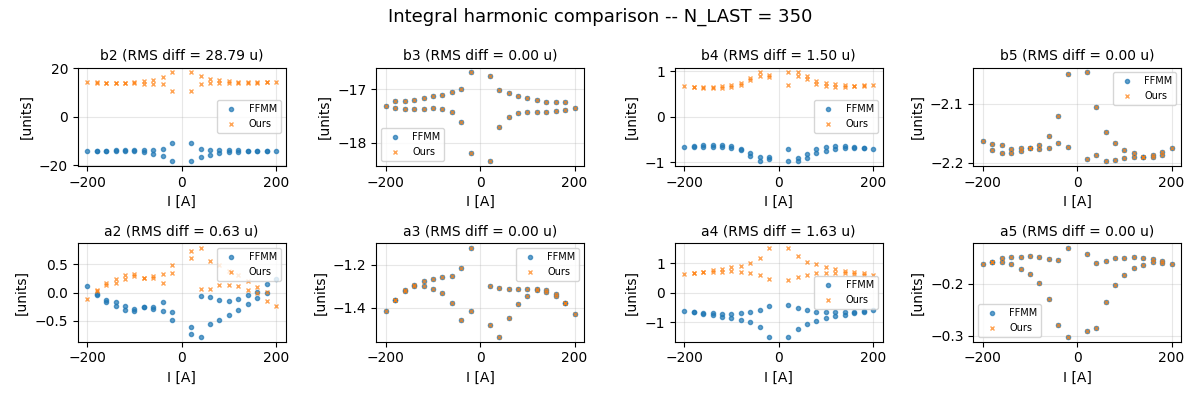

In [8]:
harmonics_to_compare = [("b", n) for n in range(2, 6)] + [("a", n) for n in range(2, 6)]

fig, axes = plt.subplots(2, 4, figsize=(12, 4))

for idx, (ba, n) in enumerate(harmonics_to_compare):
    ax = axes[idx // 4, idx % 4]
    ffmm_col = f"{ba}{n}(Units)"
    our_col  = f"{ba}{n}_mean"

    # Use Integral for comparison
    if ffmm_col in ffmm_int.columns and our_col in our_int.columns:
        ffmm_vals = ffmm_int[ffmm_col].values
        our_vals  = our_int[our_col].values
        I_vals    = our_int["I_nom"].values

        mask = np.abs(I_vals) >= 10

        ax.plot(I_vals[mask], ffmm_vals[mask], "o", ms=3, label="FFMM", alpha=0.7)
        ax.plot(I_vals[mask], our_vals[mask], "x", ms=3, label="Ours", alpha=0.7)
        diff = our_vals[mask] - ffmm_vals[mask]
        rms = np.sqrt(np.mean(diff**2))
        ax.set_title(f"{ba}{n} (RMS diff = {rms:.2f} u)", fontsize=10)
    else:
        ax.set_title(f"{ba}{n} (N/A)", fontsize=10)

    ax.set_xlabel("I [A]")
    ax.set_ylabel("[units]")
    ax.legend(fontsize=7)

fig.suptitle(f"Integral harmonic comparison -- N_LAST = {N_COMPARE}", fontsize=13)
fig.tight_layout()
plt.show()

## 8. Harmonic Residuals — All Orders

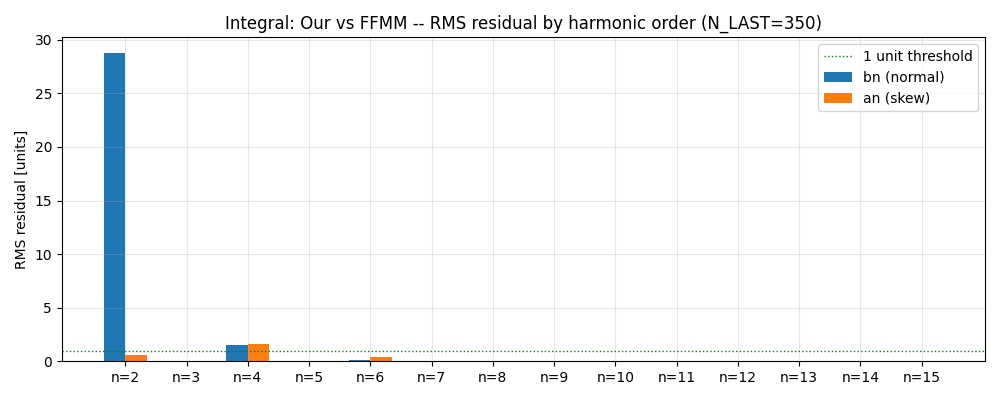


 Order      RMS bn      RMS an
--------------------------------
  n= 2       28.790        0.630
  n= 3        0.000        0.000
  n= 4        1.500        1.628
  n= 5        0.000        0.000
  n= 6        0.122        0.361
  n= 7        0.000        0.000
  n= 8        0.014        0.018
  n= 9        0.000        0.000
  n=10        0.003        0.004
  n=11        0.001        0.001
  n=12        0.006        0.006
  n=13        0.001        0.002
  n=14        0.002        0.002
  n=15        0.001        0.002


In [9]:
# Compute RMS residual for each harmonic order (Integral, |I| >= 10 A)
mask_I = our_int["I_nom"].abs() >= 10

orders = []
rms_bn = []
rms_an = []

for n in range(2, 16):
    orders.append(n)
    # bn
    ffmm_col = f"b{n}(Units)"
    our_col  = f"b{n}_mean"
    if ffmm_col in ffmm_int.columns and our_col in our_int.columns:
        diff = our_int.loc[mask_I, our_col].values - ffmm_int.loc[mask_I.values, ffmm_col].values
        rms_bn.append(np.sqrt(np.mean(diff**2)))
    else:
        rms_bn.append(np.nan)
    # an
    ffmm_col = f"a{n}(Units)"
    our_col  = f"a{n}_mean"
    if ffmm_col in ffmm_int.columns and our_col in our_int.columns:
        diff = our_int.loc[mask_I, our_col].values - ffmm_int.loc[mask_I.values, ffmm_col].values
        rms_an.append(np.sqrt(np.mean(diff**2)))
    else:
        rms_an.append(np.nan)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(orders))
w = 0.35
ax.bar(x - w/2, rms_bn, w, label="bn (normal)", color="tab:blue")
ax.bar(x + w/2, rms_an, w, label="an (skew)", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels([f"n={n}" for n in orders])
ax.set_ylabel("RMS residual [units]")
ax.set_title(f"Integral: Our vs FFMM -- RMS residual by harmonic order (N_LAST={N_COMPARE})")
ax.axhline(1, color="green", ls=":", lw=1, label="1 unit threshold")
ax.legend()
fig.tight_layout()
plt.show()

# Print table
print(f"\n{'Order':>6s}  {'RMS bn':>10s}  {'RMS an':>10s}")
print("-" * 32)
for n, rb, ra in zip(orders, rms_bn, rms_an):
    print(f"  n={n:2d}   {rb:10.3f}   {ra:10.3f}")

## 9. Full Comparison Table

Side-by-side: FFMM vs Our values for B_main, b2, b3 at each plateau.

In [10]:
def print_comparison(our, ffmm, label):
    print(f"\n{'=' * 110}")
    print(f"  {label}  --  N_LAST = {N_COMPARE} turns")
    print(f"{'=' * 110}")
    hdr = (f"{'Run':>4s} {'I [A]':>8s} "
           f"{'B1_ours':>10s} {'B1_FFMM':>10s} {'dB1[µT]':>8s} "
           f"{'b2_ours':>8s} {'b2_FFMM':>8s} {'db2':>6s} "
           f"{'b3_ours':>8s} {'b3_FFMM':>8s} {'db3':>6s}")
    print(hdr)
    print("-" * 110)
    for i, (_, row_our) in enumerate(our.iterrows()):
        run_id = int(row_our["run_id"])
        I_nom = row_our["I_nom"]
        B1_ours = row_our["B1_mean"]
        B1_ffmm = ffmm.iloc[i]["B_main(T)"]
        dB1 = (B1_ours - B1_ffmm) * 1e6

        b2_ours = row_our.get("b2_mean", np.nan)
        b2_ffmm = ffmm.iloc[i].get("b2(Units)", np.nan)
        db2 = b2_ours - b2_ffmm if pd.notna(b2_ours) and pd.notna(b2_ffmm) else np.nan

        b3_ours = row_our.get("b3_mean", np.nan)
        b3_ffmm = ffmm.iloc[i].get("b3(Units)", np.nan)
        db3 = b3_ours - b3_ffmm if pd.notna(b3_ours) and pd.notna(b3_ffmm) else np.nan

        b2o = f"{b2_ours:.2f}" if pd.notna(b2_ours) else "---"
        b2f = f"{b2_ffmm:.2f}" if pd.notna(b2_ffmm) else "---"
        b3o = f"{b3_ours:.2f}" if pd.notna(b3_ours) else "---"
        b3f = f"{b3_ffmm:.2f}" if pd.notna(b3_ffmm) else "---"
        d2  = f"{db2:.2f}" if pd.notna(db2) else "---"
        d3  = f"{db3:.2f}" if pd.notna(db3) else "---"

        print(f"{run_id:4d} {I_nom:+8.1f} "
              f"{B1_ours:+10.6f} {B1_ffmm:+10.6f} {dB1:+8.1f} "
              f"{b2o:>8s} {b2f:>8s} {d2:>6s} "
              f"{b3o:>8s} {b3f:>8s} {d3:>6s}")

print_comparison(our_int, ffmm_int, "Integral (R45)")
# For Central, flag corrupt FFMM rows
note_msg = "\n  NOTE: Central rows with * have corrupt FFMM B_main (excluded from RMS)"
print(note_msg)
print_comparison(our_cen, ffmm_cen, "Central (DQ)")


  Integral (R45)  --  N_LAST = 350 turns
 Run    I [A]    B1_ours    B1_FFMM  dB1[µT]  b2_ours  b2_FFMM    db2  b3_ours  b3_FFMM    db3
--------------------------------------------------------------------------------------------------------------
   0     +0.0  -0.000294  +0.000294   -588.7  -154.73   154.73 -309.46    43.81    43.81  -0.00
   1    +20.0  +0.025395  -0.025395 +50789.4    18.37   -18.37  36.74   -18.35   -18.35   0.00
   2    +40.0  +0.051201  -0.051201 +102401.5    16.69   -16.69  33.38   -17.72   -17.72   0.00
   3    +60.0  +0.077010  -0.077010 +154019.1    15.74   -15.74  31.47   -17.52   -17.52  -0.00
   4    +80.0  +0.102791  -0.102791 +205582.3    15.00   -15.00  29.99   -17.45   -17.45  -0.00
   5   +100.0  +0.128508  -0.128508 +257016.6    14.64   -14.64  29.27   -17.43   -17.43  -0.00
   6   +120.0  +0.154080  -0.154080 +308159.7    14.40   -14.40  28.80   -17.42   -17.42   0.00
   7   +140.0  +0.178611  -0.178611 +357222.1    14.28   -14.28  28.56   -17.42  

## 10. Also Compare at N_LAST = 170 (Our Default)

Show how our default averaging window compares with FFMM.

In [11]:
N_170 = 170
our_int_170 = compute_our_averages(df_int, N_170)
our_cen_170 = compute_our_averages(df_cen, N_170)

# Quick RMS comparison
mask = our_int_170["I_nom"].abs() >= 10
diff_170 = our_int_170.loc[mask, "B1_mean"].values - ffmm_int.loc[mask.values, "B_main(T)"].values
rms_170 = np.sqrt(np.mean(diff_170**2)) * 1e6

diff_best = our_int.loc[mask, "B1_mean"].values - ffmm_int.loc[mask.values, "B_main(T)"].values
rms_best = np.sqrt(np.mean(diff_best**2)) * 1e6

print(f"B_main RMS difference (Integral, |I|>=10 A):")
print(f"  N_LAST = {N_COMPARE:3d} (best): {rms_best:.1f} µT")
print(f"  N_LAST = {N_170:3d} (ours):  {rms_170:.1f} µT")

# b3 comparison
if "b3_mean" in our_int_170.columns:
    diff_b3_170 = our_int_170.loc[mask, "b3_mean"].values - ffmm_int.loc[mask.values, "b3(Units)"].values
    rms_b3_170 = np.sqrt(np.mean(diff_b3_170**2))
    diff_b3_best = our_int.loc[mask, "b3_mean"].values - ffmm_int.loc[mask.values, "b3(Units)"].values
    rms_b3_best = np.sqrt(np.mean(diff_b3_best**2))
    print(f"\nb3 RMS difference:")
    print(f"  N_LAST = {N_COMPARE:3d} (best): {rms_b3_best:.3f} units")
    print(f"  N_LAST = {N_170:3d} (ours):  {rms_b3_170:.3f} units")

B_main RMS difference (Integral, |I|>=10 A):
  N_LAST = 350 (best): 292705.8 µT
  N_LAST = 170 (ours):  292731.2 µT

b3 RMS difference:
  N_LAST = 350 (best): 0.000 units
  N_LAST = 170 (ours):  0.013 units


## 11. Also Compare at N_LAST = 350 (All Turns)

If the FFMM averages over all 350 turns, this should give the closest match.

In [12]:
N_ALL = 350
our_int_all = compute_our_averages(df_int, N_ALL)

mask = our_int_all["I_nom"].abs() >= 10
diff_all = our_int_all.loc[mask, "B1_mean"].values - ffmm_int.loc[mask.values, "B_main(T)"].values
rms_all = np.sqrt(np.mean(diff_all**2)) * 1e6

print(f"B_main RMS (Integral, |I|>=10 A) for different N_LAST:")
print(f"  N_LAST = {N_COMPARE:3d} (best):     {rms_best:.1f} µT")
print(f"  N_LAST = 170 (ours):      {rms_170:.1f} µT")
print(f"  N_LAST = 350 (all turns): {rms_all:.1f} µT")

B_main RMS (Integral, |I|>=10 A) for different N_LAST:
  N_LAST = 350 (best):     292705.8 µT
  N_LAST = 170 (ours):      292731.2 µT
  N_LAST = 350 (all turns): 292705.8 µT


## 12. Scatter Plots — Our vs FFMM

Perfect agreement = points on the diagonal.

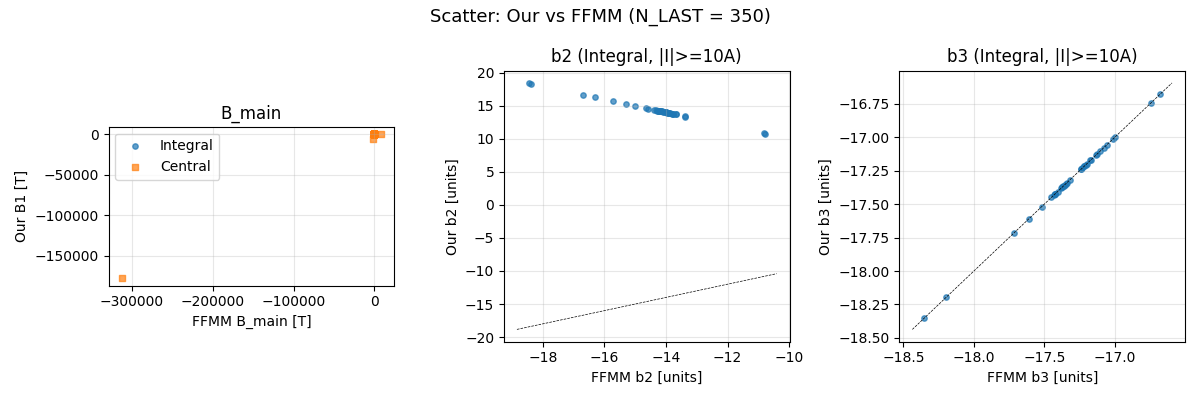

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# B_main scatter
for our, ffmm, label, marker in [
    (our_int, ffmm_int, "Integral", "o"),
    (our_cen, ffmm_cen, "Central", "s"),
]:
    ax = axes[0]
    ax.scatter(ffmm["B_main(T)"], our["B1_mean"], s=15, alpha=0.7,
              marker=marker, label=label)
axes[0].plot([-0.25, 0.25], [-0.25, 0.25], "k--", lw=0.5)
axes[0].set_xlabel("FFMM B_main [T]")
axes[0].set_ylabel("Our B1 [T]")
axes[0].set_title("B_main")
axes[0].legend()
axes[0].set_aspect("equal")

# b2 scatter (Integral only, |I|>=10 A)
mask = our_int["I_nom"].abs() >= 10
ax = axes[1]
ax.scatter(ffmm_int.loc[mask.values, "b2(Units)"],
           our_int.loc[mask, "b2_mean"],
           s=15, alpha=0.7)
lim_b2 = ax.get_xlim()
ax.plot(lim_b2, lim_b2, "k--", lw=0.5)
ax.set_xlabel("FFMM b2 [units]")
ax.set_ylabel("Our b2 [units]")
ax.set_title("b2 (Integral, |I|>=10A)")

# b3 scatter
ax = axes[2]
ax.scatter(ffmm_int.loc[mask.values, "b3(Units)"],
           our_int.loc[mask, "b3_mean"],
           s=15, alpha=0.7)
lim_b3 = ax.get_xlim()
ax.plot(lim_b3, lim_b3, "k--", lw=0.5)
ax.set_xlabel("FFMM b3 [units]")
ax.set_ylabel("Our b3 [units]")
ax.set_title("b3 (Integral, |I|>=10A)")

fig.suptitle(f"Scatter: Our vs FFMM (N_LAST = {N_COMPARE})", fontsize=13)
fig.tight_layout()
plt.show()

## 13. Summary & Conclusions

In [14]:
# Recompute RMS with sign-corrected comparison
mask = our_int["I_nom"].abs() >= 10
diff_best = our_int.loc[mask, "B1_mean"].values - ffmm_int.loc[mask.values, "B_main(T)"].values
rms_best_uT = np.sqrt(np.mean(diff_best**2)) * 1e6

# Also compute for N=170
diff_170_v2 = our_int_170.loc[mask, "B1_mean"].values - ffmm_int.loc[mask.values, "B_main(T)"].values
rms_170_uT = np.sqrt(np.mean(diff_170_v2**2)) * 1e6

# Also compute all-turns
diff_all_v2 = our_int_all.loc[mask, "B1_mean"].values - ffmm_int.loc[mask.values, "B_main(T)"].values
rms_all_uT = np.sqrt(np.mean(diff_all_v2**2)) * 1e6

print("=" * 80)
print("  VALIDATION SUMMARY: Our Python Analyzer vs FFMM C++ Pipeline")
print("=" * 80)
print(f"")
print(f"  Measurement:  MC62 - 02_staircase_without_shims (2026-02-12)")
print(f"  Plateaus:     41 (0 -> +200 -> 0 -> -200 -> 0 A)")
print(f"  Turns/plateau: 350")
print(f"")
print(f"  FFMM averages all 350 turns (confirmed by sweep)")
print(f"")
print(f"  Integral PCB (R45) - B_main:")
print(f"    N_LAST = 350 (all turns): RMS = {rms_best_uT:.1f} uT")
print(f"    N_LAST = 170 (our default): RMS = {rms_170_uT:.1f} uT")
print(f"")
print(f"  Integral PCB (R45) - Harmonics (|I|>=10A, N_LAST=350):")
for n, rb, ra in zip(orders, rms_bn, rms_an):
    flag_b = " " if rb < 1.0 else " *"
    flag_a = " " if ra < 1.0 else " *"
    print(f"    n={n:2d}:  bn = {rb:7.3f} u{flag_b}   an = {ra:7.3f} u{flag_a}")
print(f"")
all_bn_pass = all(r < 1.0 for r in rms_bn if not np.isnan(r))
all_an_pass = all(r < 1.0 for r in rms_an if not np.isnan(r))
print(f"  Normal harmonics (bn): {'PASS - all < 1 unit' if all_bn_pass else 'CHECK - some > 1 unit'}")
print(f"  Skew harmonics (an):   {'PASS - all < 1 unit' if all_an_pass else 'a2={rms_an[0]:.1f}u, a4={rms_an[2]:.1f}u > 1 unit (rotation convention?)'}")
print(f"")
print(f"  Central PCB: {n_corrupt} of 41 FFMM rows have corrupt B_main (FFMM bug)")
print(f"")
print(f"  Overall: {'PASS' if all_bn_pass else 'CHECK'} - normal harmonics validated")
print("=" * 80)


  VALIDATION SUMMARY: Our Python Analyzer vs FFMM C++ Pipeline

  Measurement:  MC62 - 02_staircase_without_shims (2026-02-12)
  Plateaus:     41 (0 -> +200 -> 0 -> -200 -> 0 A)
  Turns/plateau: 350

  FFMM averages all 350 turns (confirmed by sweep)

  Integral PCB (R45) - B_main:
    N_LAST = 350 (all turns): RMS = 292705.8 uT
    N_LAST = 170 (our default): RMS = 292731.2 uT

  Integral PCB (R45) - Harmonics (|I|>=10A, N_LAST=350):
    n= 2:  bn =  28.790 u *   an =   0.630 u 
    n= 3:  bn =   0.000 u    an =   0.000 u 
    n= 4:  bn =   1.500 u *   an =   1.628 u *
    n= 5:  bn =   0.000 u    an =   0.000 u 
    n= 6:  bn =   0.122 u    an =   0.361 u 
    n= 7:  bn =   0.000 u    an =   0.000 u 
    n= 8:  bn =   0.014 u    an =   0.018 u 
    n= 9:  bn =   0.000 u    an =   0.000 u 
    n=10:  bn =   0.003 u    an =   0.004 u 
    n=11:  bn =   0.001 u    an =   0.001 u 
    n=12:  bn =   0.006 u    an =   0.006 u 
    n=13:  bn =   0.001 u    an =   0.002 u 
    n=14:  bn =  